In [1]:
import os
import matplotlib.pyplot as plt
import sympy as sp
import numpy as np
import pandas as pd

In [2]:
sheet= pd.read_excel(r'C:\Users\neftid\Desktop\These\IJPR\use_case.xlsx', sheet_name=None)

In [3]:
A0 = sheet["A0"].iloc[:, 1:].to_numpy() # ideal linear scenario
A0

array([[    0,     0,  1000],
       [    0,  1000, -1000],
       [ 1000, -1000,     0]], dtype=int64)

In [41]:
A1 = sheet["A1"].iloc[:, 1:].to_numpy() #linear scenario
A1

In [5]:
A2 = sheet["A2"].iloc[:, 1:].to_numpy() #ciruclar scenario
A2 


array([[    0.        ,     0.        ,  1000.        ,     0.        ,
            0.        ],
       [    0.        ,  1000.        , -1310.        ,     0.        ,
            0.        ],
       [    0.        ,     0.        ,   308.        ,  -308.        ,
            0.        ],
       [    0.        ,  -235.11450382,     0.        ,   308.        ,
            0.        ],
       [ 1000.        ,  -743.6       ,     0.        ,     0.        ,
            0.        ],
       [    0.        ,   -61.3       ,     0.        ,     0.        ,
          100.        ]])

In [6]:
B0 = sheet["B0"].iloc[:, 1:].to_numpy() # ideal linear scenario

array([[-8.2808960e+01, -3.5500000e+02, -3.3800000e+02],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  4.7000000e+02,  0.0000000e+00],
       [ 0.0000000e+00,  1.2200000e-03,  0.0000000e+00],
       [ 3.0345840e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  7.8400000e-02,  9.0600000e-03],
       [ 2.0000000e-02,  3.2200000e-02,  0.0000000e+00],
       [ 1.3292088e+01,  4.8100000e-04,  4.1500000e-05],
       [ 5.3592024e-01,  6.4600000e-03,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  4.6400000e-05,  0.0000000e+00],
       [ 0.0000000e+00,  3.6200000e-02,  2.0300000e-01],
       [ 5.9160000e+03,  3.5500000e+01,  3.3800000e+01],
       [ 0.0000000e+00,  2.0300000e-04,  3.2300000e-04],
       [ 4.8439760e-01,  2.9800000e-04,  0.0000000e+00],
       [ 4.8176600e-01,  0.0000000e+00,  2.4100000e-02],
       [ 1.1750400e-04,  1.2500000e-07,  6.5100000e-04],
       [ 2.4675800e-07,  0.0000

In [42]:
B1=sheet["B1"].iloc[:, 1:].to_numpy() #linear scenario

In [43]:
B2=sheet["B2"].iloc[:, 1:].to_numpy() #circular scenario

In [44]:
C=sheet["C"].iloc[:, 1:].to_numpy()

In [10]:
F0=sheet["F0"].iloc[:, 1:].to_numpy()
F0

array([[1000],
       [   0],
       [   0]], dtype=int64)

In [11]:
F=sheet["F"].iloc[:, 1:].to_numpy()
F

array([[1000],
       [   0],
       [   0],
       [   0],
       [   0],
       [   0]], dtype=int64)

In [12]:
def scaling(A, F):
    A = sp.Matrix(A)
    F = sp.Matrix(F)

    if A.rows != F.rows:
        raise ValueError(
            "The number of rows in the technosphere matrix 'A' must be equal to the number of rows in vector demand 'F'."
        )

    variables = sp.symbols(f"s1:{A.cols + 1}")
    sol = sp.linsolve((A, F), *variables)
    
    if not sol:
        raise ValueError("No solution found for the scaling system.")
    
    sol_tuple = list(sol)[0]
    if any(isinstance(x, sp.Basic) and x.free_symbols for x in sol_tuple):
        raise ValueError("The system has infinit solutions.")
    return np.array(sol_tuple, dtype=float)

In [13]:
s0=scaling(A0, F0)

In [14]:
s1=scaling(A1, F0)

In [15]:
s2=scaling(A2, F)

In [16]:
def L(C,B,s):
    s = np.array(s, dtype=float).reshape(-1)
    Q=np.dot(C,B)
    return np.dot(Q,s)

In [17]:
h0=L(C,B0,s0)
h0

array([7.75808960e+02, 1.44165463e+01, 4.19828188e+00, 3.16510000e+00,
       3.19141200e+00, 3.73400000e-05, 1.26000000e+05, 1.95146400e+03,
       0.00000000e+00])

In [18]:
h1=L(C,B1,s1)
h1

array([9.15870012e+02, 1.96385900e+01, 5.71896937e+00, 4.29119695e+00,
       4.31874337e+00, 4.62370000e-05, 1.71664051e+05, 2.65870012e+03,
       3.62413100e+02])

In [19]:
h2=L(C,B2,s2)
h2

array([8.83715533e+02, 1.41121837e+01, 4.11032182e+00, 3.22228015e+00,
       3.25024174e+00, 4.62370000e-05, 1.23705738e+05, 2.02002819e+03,
       5.44131000e+01])

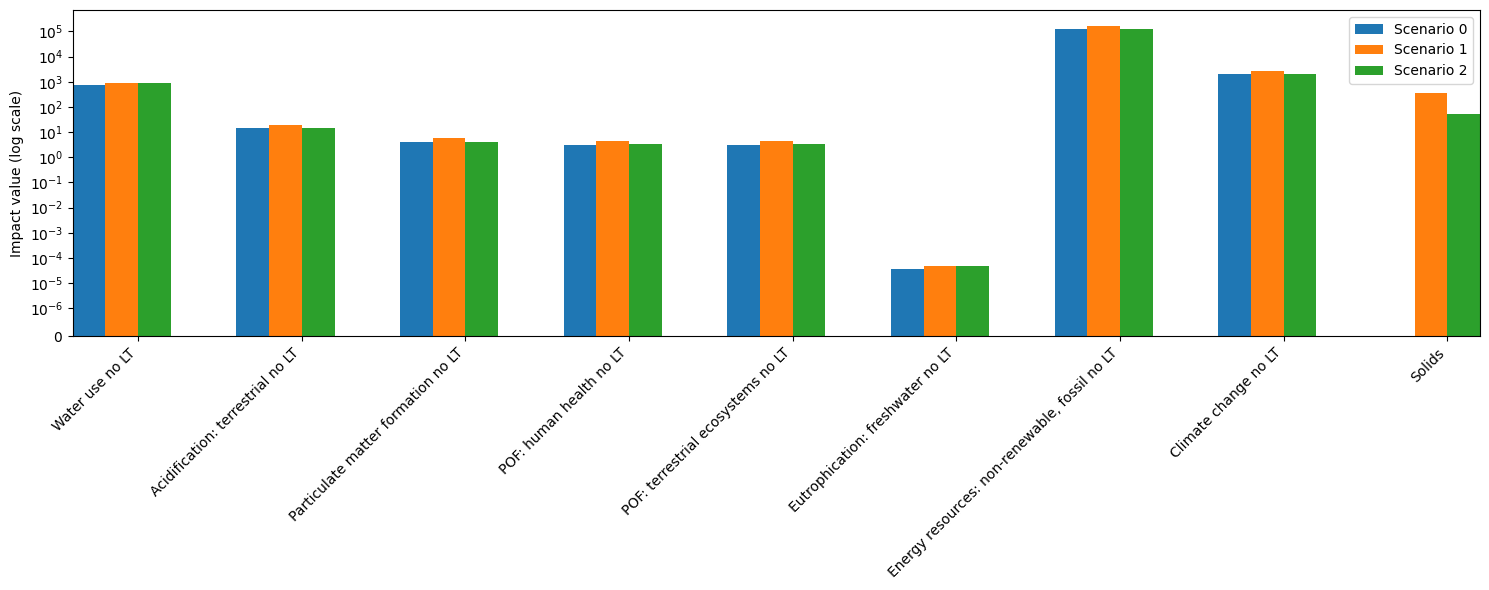

In [23]:
categories = [
    "Water use no LT",
    "Acidification: terrestrial no LT",
    "Particulate matter formation no LT",
    "POF: human health no LT",
    "POF: terrestrial ecosystems no LT",
    "Eutrophication: freshwater no LT",
    "Energy resources: non-renewable, fossil no LT",
    "Climate change no LT",
    "Solids"
]
x = np.arange(len(categories))
width = 0.2

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(x - 1.5*width, h0, width, label="Scenario 0")
ax.bar(x - 0.5*width, h1, width, label="Scenario 1")
ax.bar(x + 0.5*width, h2, width, label="Scenario 2")
ax.set_ylabel("Impact value (log scale)")
ax.set_yscale("symlog", linthresh=1e-6)
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha="right")
ax.legend()
plt.tight_layout()
ax.autoscale(enable=True, axis='x', tight=True)
plt.savefig("impact_fresult.png", dpi=300, bbox_inches='tight', pad_inches=0.05)
plt.show()